In [ ]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

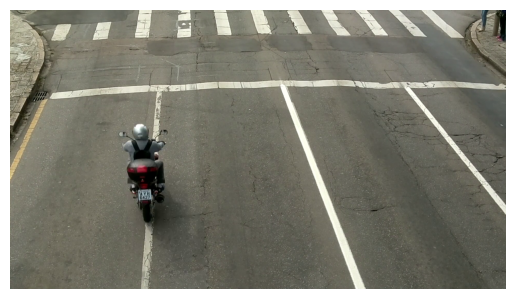

In [1]:
#ver el frame 58 de el video, graficar en el notebook
import cv2
import matplotlib.pyplot as plt
video_path = 'video01/video.mp4'
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 58)
ret, frame = cap.read()
if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.show()
cap.release()   

In [2]:
#cantidad de frames del video
cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f'Total frames in the video: {total_frames}')
#fps del video
fps = cap.get(cv2.CAP_PROP_FPS)
print(f'Frames per second (FPS): {fps}')

#largo del video en minutos:segundos
duration_seconds = total_frames / fps
minutes = int(duration_seconds // 60)
seconds = int(duration_seconds % 60)
print(f'Video duration: {minutes} minutes and {seconds} seconds')

Total frames in the video: 6918
Frames per second (FPS): 25.0
Video duration: 4 minutes and 36 seconds


In [3]:
from ultralytics import YOLO
import cv2
import csv
import os

# --------- CONFIG ---------
video_path = "video01/video.mp4"
model_path = "yolo11s.pt"    # tu modelo YOLO
output_csv = "vehicle_tracks_yolo.csv"
output_video = "video_annotated.mp4"

# clases de vehículos (COCO)
VEHICLE_CLASSES = {"car", "truck", "bus", "motorbike"}

# --------- INFO DEL VIDEO ---------
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError(f"No se pudo abrir el video: {video_path}")

fps = cap.get(cv2.CAP_PROP_FPS)
img_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
img_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cap.release()

video_id = os.path.splitext(os.path.basename(video_path))[0]

print(f"Video: {video_id}, fps={fps}, size=({img_w}x{img_h})")

# --------- PREPARAR VIDEO DE SALIDA ---------
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(output_video, fourcc, fps, (img_w, img_h))

# --------- CARGAR MODELO YOLO ---------
model = YOLO(model_path)

# --------- CSV ---------
fieldnames = [
    "video_id",
    "frame",
    "track_id",
    "class_id",
    "class_name",
    "conf",
    "x1", "y1", "x2", "y2",
    "img_w", "img_h",
    "fps",
]

csv_file = open(output_csv, "w", newline="")
writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
writer.writeheader()

# --------- TRACKING ---------
results = model.track(
    source=video_path,
    stream=True,
    tracker="bytetrack.yaml",
    persist=True
)

frame_idx = 0
for r in results:
    # Leer frame actual
    frame = r.orig_img.copy()

    if r.boxes is None or r.boxes.id is None:
        out.write(frame)
        frame_idx += 1
        continue

    boxes = r.boxes.xyxy.cpu().numpy()
    ids   = r.boxes.id.cpu().numpy().astype(int)
    clss  = r.boxes.cls.cpu().numpy().astype(int)
    confs = r.boxes.conf.cpu().numpy()
    names = r.names

    for (x1, y1, x2, y2), tid, cid, conf in zip(boxes, ids, clss, confs):
        class_name = names[int(cid)]

        # filtrar solo vehículos
        if class_name not in VEHICLE_CLASSES:
            continue

        # ---- Guardar en CSV ----
        row = {
            "video_id":  video_id,
            "frame":     frame_idx,
            "track_id":  int(tid),
            "class_id":  int(cid),
            "class_name": class_name,
            "conf":      float(conf),
            "x1":        float(x1),
            "y1":        float(y1),
            "x2":        float(x2),
            "y2":        float(y2),
            "img_w":     img_w,
            "img_h":     img_h,
            "fps":       fps,
        }
        writer.writerow(row)

        # ---- Dibujar bounding box ----
        cv2.rectangle(frame,
                      (int(x1), int(y1)),
                      (int(x2), int(y2)),
                      (0, 255, 0), 2)

        # centro de la base
        cx = int((x1 + x2) / 2)
        cy = int(y2)
        cv2.circle(frame, (cx, cy), 5, (0, 0, 255), -1)

        # texto
        label = f"ID={tid} {class_name} {conf:.2f}"
        cv2.putText(frame, label,
                    (int(x1), max(int(y1) - 5, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, (0, 255, 0), 2)

    # escribir frame anotado
    out.write(frame)
    frame_idx += 1

csv_file.close()
out.release()

print(f"\n➡ CSV guardado en: {output_csv}")
print(f"➡ Video anotado guardado en: {output_video}")


Video: video, fps=25.0, size=(1920x1080)

video 1/1 (frame 1/6918) c:\Users\Mati\Desktop\VisionTrafficGuard\speed\video01\video.mp4: 384x640 1 car, 1 truck, 81.6ms
video 1/1 (frame 2/6918) c:\Users\Mati\Desktop\VisionTrafficGuard\speed\video01\video.mp4: 384x640 1 car, 1 truck, 65.0ms
video 1/1 (frame 3/6918) c:\Users\Mati\Desktop\VisionTrafficGuard\speed\video01\video.mp4: 384x640 1 truck, 70.0ms
video 1/1 (frame 4/6918) c:\Users\Mati\Desktop\VisionTrafficGuard\speed\video01\video.mp4: 384x640 2 persons, 1 bus, 67.7ms
video 1/1 (frame 5/6918) c:\Users\Mati\Desktop\VisionTrafficGuard\speed\video01\video.mp4: 384x640 1 person, 62.2ms
video 1/1 (frame 6/6918) c:\Users\Mati\Desktop\VisionTrafficGuard\speed\video01\video.mp4: 384x640 1 person, 62.0ms
video 1/1 (frame 7/6918) c:\Users\Mati\Desktop\VisionTrafficGuard\speed\video01\video.mp4: 384x640 1 person, 68.3ms
video 1/1 (frame 8/6918) c:\Users\Mati\Desktop\VisionTrafficGuard\speed\video01\video.mp4: 384x640 1 person, 69.2ms
video 1/1 (

In [4]:
#mostrar el frame 58 del video raw y del video procesado
import cv2
import matplotlib.pyplot as plt
video_path_processed = 'runs/detect/predict/video.avi'
cap_raw = cv2.VideoCapture(video_path)
cap_processed = cv2.VideoCapture(video_path_processed)
cap_raw.set(cv2.CAP_PROP_POS_FRAMES, 58)
cap_processed.set(cv2.CAP_PROP_POS_FRAMES, 58)
ret_raw, frame_raw = cap_raw.read()
ret_processed, frame_processed = cap_processed.read()
if ret_raw and ret_processed:
    frame_raw_rgb = cv2.cvtColor(frame_raw, cv2.COLOR_BGR2RGB)
    frame_processed_rgb = cv2.cvtColor(frame_processed, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title('Raw Frame 58')
    plt.imshow(frame_raw_rgb)
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.title('Processed Frame 58')
    plt.imshow(frame_processed_rgb)
    plt.axis('off')
    plt.show()

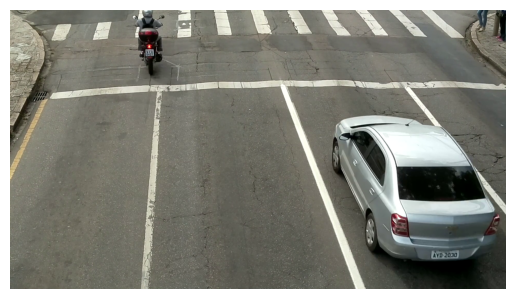

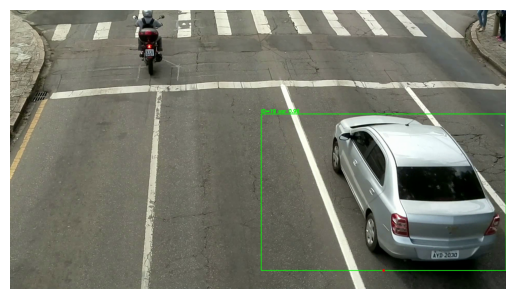

In [1]:
#mostrar frame 71 del video raw y del video procesado
import cv2
import matplotlib.pyplot as plt
video_path = 'video01/video.mp4'
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 71)
ret, frame = cap.read()
if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.show()

video_path = 'video_annotated.mp4'
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, 71)
ret, frame = cap.read()
if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.imshow(frame_rgb)
    plt.axis('off')
    plt.show()



hay que poder relacionar el ground truth con lo que detecto nuestro modelo

In [3]:
#a partir del csv generado, calcular el centro en x y en y de cada bounding box
import pandas as pd
df = pd.read_csv('video01/vehicle_tracks_yolo.csv')

df['center_x'] = (df['x1'] + df['x2']) / 2
df['center_y'] = (df['y1'] + df['y2']) / 2

#guardar en el mismo csv
df.to_csv('video01/vehicle_tracks_yolo.csv', index=False)

## quiero ver a que se refieren el x e y del xml

BBOX GT: x=1632, y=930, w=106, h=35, centro=(1685.0, 947.5)


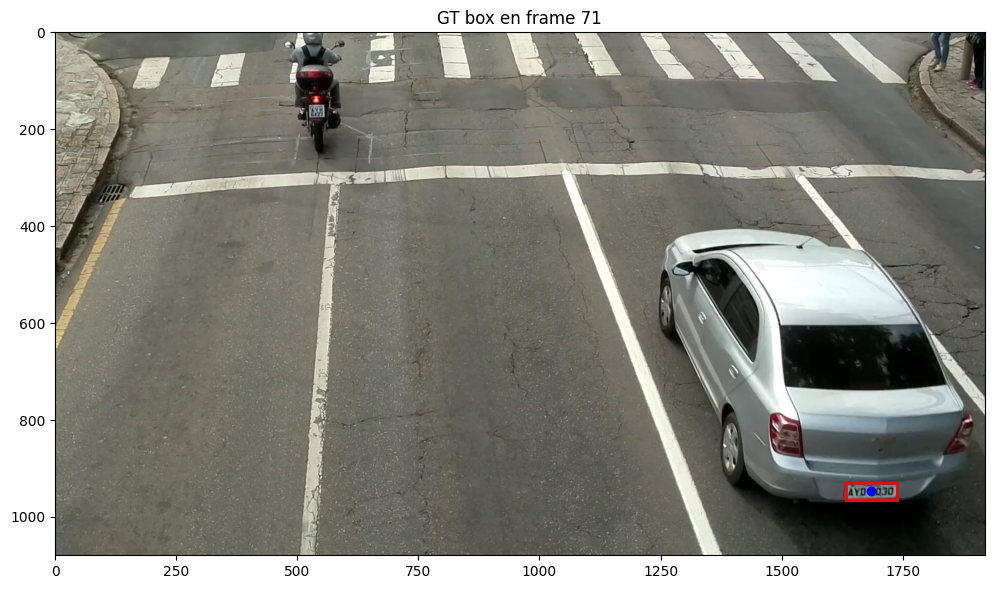

In [11]:
import xml.etree.ElementTree as ET
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# === 1) CARGAR XML ========================================================
xml_path = "video01/vehicles.xml"
tree = ET.parse(xml_path)
root = tree.getroot()
gtruth = root.find("gtruth")

# Vehículo que te interesa (iframe=71)
target_frame = 71

vehicle = None
for v in gtruth.findall("vehicle"):
    if int(v.get("iframe")) == target_frame:
        vehicle = v
        break

if vehicle is None:
    print(f"No hay vehicle con iframe={target_frame} en el XML.")
    exit()

# Extraer region del XML
region = vehicle.find("region")
x = int(region.get("x"))
y = int(region.get("y"))
w = int(region.get("w"))
h = int(region.get("h"))

cx = x + w/2
cy = y + h/2

print(f"BBOX GT: x={x}, y={y}, w={w}, h={h}, centro=({cx:.1f}, {cy:.1f})")


# === 2) CARGAR FRAME DEL VIDEO ORIGINAL ==================================
video_path = "video01/video.mp4"   # <-- NO USES EL ANNOTATED
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    raise RuntimeError("No se pudo abrir el video.")

# posicionarte en el frame correcto
cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
ret, frame = cap.read()

if not ret:
    raise RuntimeError(f"No se pudo leer el frame {target_frame}. Revisa la duración del video.")

# convertir BGR → RGB
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


# === 3) DIBUJAR ==========================================================
fig, ax = plt.subplots(figsize=(12, 7))
ax.imshow(frame_rgb)

# rectángulo rojo
rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect)

# centro de la bbox
ax.plot(cx, cy, 'bo', markersize=6)

ax.set_title(f"GT box en frame {target_frame}")
plt.show()


### x e y en vehicles.xml : el centro de la patente

In [12]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np


# ======================================================
# 1) Cargar GT desde vehicles_with_speed.xml
#    (YA LIMPIO: solo radar=True y con vehicle_id)
# ======================================================

xml_path = "video01/vehicles_with_speed.xml"

def load_gt_vehicles(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    gtruth = root.find("gtruth")

    vehicles = []

    for v in gtruth.findall("vehicle"):

        # IDs siempre presentes
        vehicle_id = int(v.get("vehicle_id"))
        iframe     = int(v.get("iframe"))
        lane       = int(v.get("lane"))

        region = v.find("region")

        # ⚠️ En ESTE DATASET, x,y YA SON EL PUNTO (centro del objeto)
        pt_x = int(region.get("x"))
        pt_y = int(region.get("y"))

        w = int(region.get("w"))
        h = int(region.get("h"))

        radar_node = v.find("radar")
        frame_start = int(radar_node.get("frame_start"))
        frame_end   = int(radar_node.get("frame_end"))
        speed_gt    = float(radar_node.get("speed"))

        vehicles.append({
            "vehicle_id": vehicle_id,
            "iframe": iframe,
            "lane": lane,
            "frame_start": frame_start,
            "frame_end": frame_end,
            "speed_gt": speed_gt,

            # punto GT
            "pt_x": pt_x,
            "pt_y": pt_y,

            # bbox opcional
            "reg_w": w,
            "reg_h": h,
        })

    return pd.DataFrame(vehicles)


gt_df = load_gt_vehicles(xml_path)
print("Vehículos GT (con radar):", len(gt_df))
display(gt_df.head())



# ======================================================
# 2) Cargar CSV de YOLO (detecciones con track_id)
# ======================================================

yolo_csv_path = "video01/vehicle_tracks_yolo_with_id.csv"
df_yolo = pd.read_csv(yolo_csv_path)

# Normalizar tipos
for col in ["x1", "y1", "x2", "y2", "frame"]:
    df_yolo[col] = df_yolo[col].astype(float)

df_yolo["frame"] = df_yolo["frame"].astype(int)
df_yolo["track_id"] = df_yolo["track_id"].astype(int)



# ======================================================
# 3) Función auxiliar: punto dentro de bbox
# ======================================================

def point_in_bbox(px, py, x1, y1, x2, y2):
    return (px >= x1) and (px <= x2) and (py >= y1) and (py <= y2)



# ======================================================
# 4) Matching: vehicle_id → track_id
# ======================================================

def match_single_vehicle(row_gt, df_yolo, max_dist_fallback=80, use_lane_if_available=True):
    """
    row_gt: fila del GT
    df_yolo: detecciones YOLO
    Devuelve: track_id o None
    """

    iframe = int(row_gt["iframe"])
    lane_gt = int(row_gt["lane"])

    # Usamos directamente el punto del GT
    cx = row_gt["pt_x"]
    cy = row_gt["pt_y"]

    df_frame = df_yolo[df_yolo["frame"] == iframe].copy()
    if df_frame.empty:
        return None

    # Si YOLO tuviera lane_id, se podría usar aquí:
    if use_lane_if_available and ("lane_id" in df_frame.columns):
        df_lane = df_frame[df_frame["lane_id"] == lane_gt]
        if not df_lane.empty:
            df_frame = df_lane

    # =================================================
    # 1) MATCH FUERTE: el punto GT cae dentro de bbox YOLO
    # =================================================
    strong_candidates = []

    for _, d in df_frame.iterrows():
        x1, y1, x2, y2 = d["x1"], d["y1"], d["x2"], d["y2"]

        if point_in_bbox(cx, cy, x1, y1, x2, y2):
            veh_cx = d.get("cx", (x1 + x2) / 2.0)
            veh_cy = d.get("cy", (y1 + y2) / 2.0)
            dist = np.hypot(veh_cx - cx, veh_cy - cy)
            strong_candidates.append((dist, int(d["track_id"])))

    if len(strong_candidates) == 1:
        return strong_candidates[0][1]

    if len(strong_candidates) > 1:
        strong_candidates.sort(key=lambda x: x[0])
        return strong_candidates[0][1]

    # =================================================
    # 2) FALLBACK: bbox más cercana
    # =================================================
    fallback = []

    for _, d in df_frame.iterrows():
        x1, y1, x2, y2 = d["x1"], d["y1"], d["x2"], d["y2"]
        veh_cx = d.get("cx", (x1 + x2) / 2.0)
        veh_cy = d.get("cy", (y1 + y2) / 2.0)
        dist = np.hypot(veh_cx - cx, veh_cy - cy)
        fallback.append((dist, int(d["track_id"])))

    fallback.sort(key=lambda x: x[0])
    best_dist, best_track = fallback[0]

    if best_dist <= max_dist_fallback:
        return best_track

    return None



# ======================================================
# 5) Crear track_id → vehicle_id y track_id → lane
# ======================================================

track_to_vehicle = {}
track_to_lane = {}

for _, row in gt_df.iterrows():
    tid = match_single_vehicle(row, df_yolo)

    if tid is not None:
        tid = int(tid)
        vid = int(row["vehicle_id"])
        ln  = int(row["lane"])

        if tid not in track_to_vehicle:
            track_to_vehicle[tid] = vid
            track_to_lane[tid] = ln
        else:
            # opcional: verificar consistencia
            if track_to_vehicle[tid] != vid or track_to_lane[tid] != ln:
                print(f"[WARN] Inconsistencia: track {tid} ya asignado a vehicle "
                      f"{track_to_vehicle[tid]} lane {track_to_lane[tid]}, "
                      f"pero aparece {vid}/{ln}")


print("\nEjemplos de mapeos track_id → (vehicle_id, lane):")
for k in list(track_to_vehicle.keys())[:10]:
    print(f"track_id {k} → vehicle_id {track_to_vehicle[k]}, lane {track_to_lane[k]}")



# ======================================================
# 6) Agregar vehicle_id y lane al CSV de YOLO
# ======================================================

df_yolo["vehicle_id"] = df_yolo["track_id"].map(track_to_vehicle)
df_yolo["lane"] = df_yolo["track_id"].map(track_to_lane)

print("\nPrimeras filas YA ENRIQUECIDAS:")
display(df_yolo.head())


output_csv = "video01/vehicle_tracks_yolo_with_id.csv"
df_yolo.to_csv(output_csv, index=False)

print(f"\nCSV enriquecido guardado en: {output_csv}")


Vehículos GT (con radar): 110


,vehicle_id,iframe,lane,frame_start,frame_end,speed_gt,pt_x,pt_y,reg_w,reg_h
0,1,71,3,71,111,56.65,1632,930,106,35
1,2,107,3,107,147,53.74,1563,896,103,27
2,3,187,2,187,227,52.13,880,926,108,28
3,4,245,3,245,285,49.06,1722,892,103,32
4,5,253,2,253,293,50.51,843,938,103,28



Ejemplos de mapeos track_id → (vehicle_id, lane):
track_id 19 → vehicle_id 1, lane 3
track_id 29 → vehicle_id 2, lane 3
track_id 46 → vehicle_id 3, lane 2
track_id 51 → vehicle_id 4, lane 3
track_id 53 → vehicle_id 5, lane 2
track_id 55 → vehicle_id 6, lane 3
track_id 61 → vehicle_id 7, lane 1
track_id 74 → vehicle_id 9, lane 3
track_id 78 → vehicle_id 10, lane 3
track_id 97 → vehicle_id 12, lane 2

Primeras filas YA ENRIQUECIDAS:


,video_id,frame,track_id,class_id,class_name,conf,x1,y1,x2,y2,img_w,img_h,fps,center_x,center_y,vehicle_id,lane
0,video,0,1,2,car,0.422626,334.997620,0.0,549.908020,53.978405,1920,1080,25.0,442.452820,26.989202,NaN,NaN
1,video,0,2,7,truck,0.377719,1058.240112,0.0,1343.984985,93.138657,1920,1080,25.0,1201.112549,46.569328,NaN,NaN
2,video,1,1,2,car,0.523622,359.220612,0.0,535.078064,43.986061,1920,1080,25.0,447.149338,21.993031,NaN,NaN
3,video,1,2,7,truck,0.518423,1077.124634,0.0,1305.382446,74.068459,1920,1080,25.0,1191.253540,37.034229,NaN,NaN
4,video,2,2,7,truck,0.352585,1087.623535,0.0,1269.353271,58.196693,1920,1080,25.0,1178.488403,29.098347,NaN,NaN



CSV enriquecido guardado en: video01/vehicle_tracks_yolo_with_id.csv


# PRIMER MODELO GEOMETRICO

## tenemos que tener puntos sobre el plano.
tenemos las medidas de los carriles, con puntos que definen cajones. En el paper nombran un cajon de 4.8 x 2m, quizas es este PERO NO ESTOY SEGURO, LO VOY A HACER ASUMIENDO QUE SI ES

Puntos del measure 3
TopLeft : (974, 41)
TopRight: (1327, 37)
BotLeft : (1090, 360)
BotRight: (1591, 373)


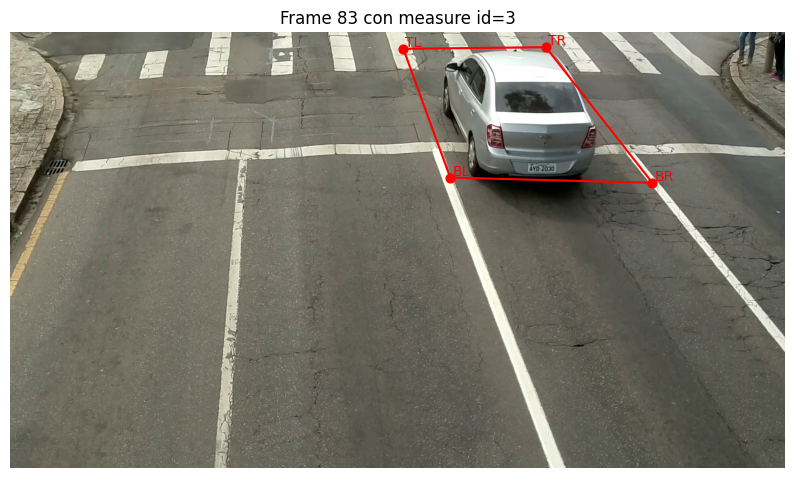

In [13]:
import xml.etree.ElementTree as ET
import cv2
import matplotlib.pyplot as plt

# ---------- Parámetros ----------
lanes_xml_path = "lanes.xml"      # ruta al XML de carriles
video_path     = "video01/video.mp4"      # ruta al video
frame_idx      = 83                    # frame a mostrar
measure_id     = "3"                      # id del <measure> a graficar

# ---------- 1) Cargar puntos del measure ----------
tree = ET.parse(lanes_xml_path)
root = tree.getroot()

lanes = root.find("lanes")

measure = None
for m in lanes.findall("measure"):
    if m.get("id") == measure_id:
        measure = m
        break

if measure is None:
    raise ValueError(f"No se encontró <measure id='{measure_id}'> en {lanes_xml_path}")

def get_xy(node_name):
    node = measure.find(node_name)
    return int(node.get("x")), int(node.get("y"))

pt_tl = get_xy("pTopLeft")
pt_tr = get_xy("pTopRight")
pt_bl = get_xy("pBotLeft")
pt_br = get_xy("pBotRight")

print("Puntos del measure", measure_id)
print("TopLeft :", pt_tl)
print("TopRight:", pt_tr)
print("BotLeft :", pt_bl)
print("BotRight:", pt_br)

# ---------- 2) Cargar frame del video ----------
cap = cv2.VideoCapture(video_path)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError(f"No se pudo leer el frame {frame_idx} de {video_path}")

# BGR -> RGB para matplotlib
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# ---------- 3) Graficar ----------
plt.figure(figsize=(10, 6))
plt.imshow(frame_rgb)
ax = plt.gca()

# puntos
for (x, y), label in zip(
    [pt_tl, pt_tr, pt_bl, pt_br],
    ["TL", "TR", "BL", "BR"]
):
    ax.scatter(x, y, s=40, c="red")
    ax.text(x + 5, y - 5, label, color="red", fontsize=10)

# unir en rectángulo
xs = [pt_tl[0], pt_tr[0], pt_br[0], pt_bl[0], pt_tl[0]]
ys = [pt_tl[1], pt_tr[1], pt_br[1], pt_bl[1], pt_tl[1]]
ax.plot(xs, ys, "r-")

plt.title(f"Frame {frame_idx} con measure id={measure_id}")
plt.axis("off")
plt.show()


version usando todos los frames en los que aparece

In [30]:
import pandas as pd
import numpy as np
import cv2
import xml.etree.ElementTree as ET

# --- 1. CONFIGURACIÓN (LO QUE FALTABA) ---
# Asumimos las medidas del paper (ajusta si tus medidas reales son otras)
# Nota: En visión computarizada vehicular, X suele ser ancho, Y profundidad (avance).
REAL_WIDTH = 2.0  # metros (ancho del rectángulo)
REAL_LENGTH = 4.8 # metros (largo del rectángulo)

# Definimos las coordenadas reales de las 4 esquinas (TopLeft es 0,0)
# Orden: TopLeft, TopRight, BotRight, BotLeft (Sentido horario o consistente con XML)
src_real_points = np.array([
    [0, 0],             # TopLeft
    [REAL_WIDTH, 0],    # TopRight
    [0, REAL_LENGTH],   # BotLeft (Ojo: en imagen Y crece hacia abajo)
    [REAL_WIDTH, REAL_LENGTH] # BotRight
], dtype=np.float32)

# --- 2. PARSEAR XML PARA OBTENER PUNTOS DE IMAGEN ---
def get_homographies_from_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    homographies = {}
    
    # Iterar sobre las medidas de cada carril
    for measure in root.findall(".//measure"):
        lane_id = int(measure.get('id'))
        
        # Extraer puntos del XML
        pt_tl = measure.find('pTopLeft')
        pt_tr = measure.find('pTopRight')
        pt_bl = measure.find('pBotLeft')
        pt_br = measure.find('pBotRight')
        
        # Crear array de puntos destino (en la imagen)
        # IMPORTANTE: El orden debe coincidir con src_real_points
        # Usamos: TL, TR, BL, BR para coincidir con mi definición arriba
        dst_img_points = np.array([
            [float(pt_tl.get('x')), float(pt_tl.get('y'))], # TopLeft
            [float(pt_tr.get('x')), float(pt_tr.get('y'))], # TopRight
            [float(pt_bl.get('x')), float(pt_bl.get('y'))], # BotLeft
            [float(pt_br.get('x')), float(pt_br.get('y'))]  # BotRight
        ], dtype=np.float32)
        
        # Calcular Homografía: De Imagen (dst) -> Mundo Real (src)
        # Nota: cv2.findHomography(puntos_origen, puntos_destino)
        # Queremos: H * pixel = metro. Por tanto input=pixel, output=metro.
        H, status = cv2.findHomography(dst_img_points, src_real_points)
        homographies[lane_id] = H
        
    return homographies

# --- 3. FUNCIÓN PARA TRANSFORMAR PUNTOS ---
def pixel_to_world(H, u, v):
    # Convertir a coordenadas homogéneas
    point_pixel = np.array([u, v, 1]).reshape(3, 1)
    point_world = np.dot(H, point_pixel)
    
    # Normalizar (dividir por w)
    x_real = point_world[0] / point_world[2]
    y_real = point_world[1] / point_world[2]
    
    return x_real[0], y_real[0]

# --- 4. PROCESAMIENTO PRINCIPAL ---
homographies = get_homographies_from_xml('lanes.xml')
df = pd.read_csv('video01/vehicle_tracks_yolo_with_id.csv')

# Filtramos solo lo necesario y ordenamos
df = df.sort_values(by=['vehicle_id', 'frame'])

vehicle_speeds = []

for vid, track in df.groupby('vehicle_id'):
    if len(track) < 2: continue # Ignorar tracks muy cortos
    
    # Obtener el carril (asumimos que no cambia drásticamente)
    try:
        lane_id = int(track.iloc[0]['lane'])
    except:
        continue # Si no tiene carril asignado
        
    if lane_id not in homographies:
        continue

    H = homographies[lane_id]
    fps = track.iloc[0]['fps']
    
    # Tomamos el primer y último punto confiable del track
    # USAMOS: Centro inferior de la caja (Bottom Center) -> Mejor precisión
    # x = (x1 + x2) / 2
    # y = y2 (la parte que toca el suelo)
    
    start_row = track.iloc[0]
    end_row = track.iloc[-1]
    
    u1 = (start_row['x1'] + start_row['x2']) / 2
    v1 = start_row['y2'] 
    
    u2 = (end_row['x1'] + end_row['x2']) / 2
    v2 = end_row['y2']
    
    # Transformar a metros
    x_real1, y_real1 = pixel_to_world(H, u1, v1)
    x_real2, y_real2 = pixel_to_world(H, u2, v2)
    
    # Calcular distancia y tiempo
    distance = np.sqrt((x_real2 - x_real1)**2 + (y_real2 - y_real1)**2) # Metros
    time_sec = (end_row['frame'] - start_row['frame']) / fps
    
    if time_sec > 0:
        speed_mps = distance / time_sec
        speed_kmh = speed_mps * 3.6
        vehicle_speeds.append({'vehicle_id': vid, 'speed_kmh': speed_kmh, 'lane': lane_id})

# --- RESULTADOS ---
results_df = pd.DataFrame(vehicle_speeds)
print(results_df.head(10))
print(f"Velocidad promedio detectada: {results_df['speed_kmh'].mean():.2f} km/h")

   vehicle_id  speed_kmh  lane
0         1.0  25.317815     3
1         2.0  24.370560     3
2         3.0  30.430749     2
3         4.0  22.961604     3
4         5.0  30.122570     2
5         6.0  22.496321     3
6         7.0  38.660139     1
7         9.0  25.842474     3
8        10.0  22.889327     3
9        12.0  25.353417     2
Velocidad promedio detectada: 21.80 km/h



=== MÉTRICAS DE DESEMPEÑO ===
MAE (Error Medio Absoluto): 22.8834
RMSE (Raíz del Error Cuadrático Medio): 23.5309
MAPE (Error Porcentual Medio): 52.6287
R2 Score (Coeficiente de Determinación): -3.6558
Total Vehículos Comparados: 104.0000

=== DETALLE POR VEHÍCULO (Primeros 5) ===
   vehicle_id  gt_speed  speed_kmh      error  rel_error_pct
0         1.0     56.65  25.317815 -31.332185      55.308359
1         2.0     53.74  24.370560 -29.369440      54.650987
2         3.0     52.13  30.430749 -21.699251      41.625266
3         4.0     49.06  22.961604 -26.098396      53.196895
4         5.0     50.51  30.122570 -20.387430      40.363155


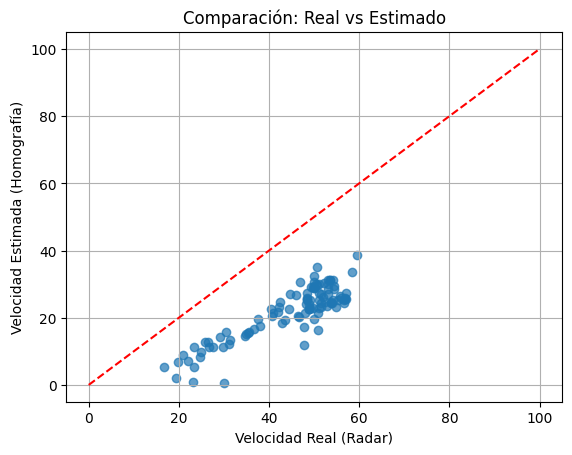

In [31]:
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# --- 1. FUNCIÓN PARA LEER EL GROUND TRUTH (XML) ---
def load_ground_truth(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    gt_data = []
    
    # Iterar sobre cada vehículo en el XML
    for vehicle in root.findall(".//vehicle"):
        try:
            v_id = int(vehicle.get('vehicle_id'))
            
            # Buscar el tag <radar> dentro del vehículo
            radar = vehicle.find('radar')
            if radar is not None:
                speed = float(radar.get('speed'))
                gt_data.append({'vehicle_id': v_id, 'gt_speed': speed})
        except (ValueError, AttributeError):
            continue # Saltar si faltan datos
            
    return pd.DataFrame(gt_data)

# --- 2. FUNCIÓN DE COMPARACIÓN Y MÉTRICAS ---
def compare_results(predicted_df, gt_xml_path):
    # Cargar datos reales
    gt_df = load_ground_truth(gt_xml_path)
    
    # Unir los dos DataFrames por 'vehicle_id' (Inner Join)
    # Esto automáticamente descarta los que no tienen coincidencia
    merged = pd.merge(predicted_df, gt_df, on='vehicle_id', how='inner')
    
    if merged.empty:
        return "Error: No se encontraron coincidencias de ID entre predicción y Ground Truth."
    
    # Calcular errores individuales
    merged['error'] = merged['speed_kmh'] - merged['gt_speed'] # Diferencia
    merged['abs_error'] = merged['error'].abs()                # Error absoluto
    merged['rel_error_pct'] = (merged['abs_error'] / merged['gt_speed']) * 100 # Error porcentual
    
    # --- CÁLCULO DE MÉTRICAS GLOBALES ---
    y_true = merged['gt_speed']
    y_pred = merged['speed_kmh']
    
    metrics = {
        "MAE (Error Medio Absoluto)": mean_absolute_error(y_true, y_pred),
        "RMSE (Raíz del Error Cuadrático Medio)": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE (Error Porcentual Medio)": np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        "R2 Score (Coeficiente de Determinación)": r2_score(y_true, y_pred),
        "Total Vehículos Comparados": len(merged)
    }
    
    return metrics, merged

# --- EJECUCIÓN (Asumiendo que ya tienes results_df del paso anterior) ---
# Si necesitas probarlo rápido, descomenta la línea de abajo para cargar tus resultados previos:
# results_df = pd.read_csv('tu_archivo_de_resultados.csv') 

metrics, comparison_df = compare_results(results_df, 'video01/vehicles_with_speed.xml')

# Mostrar Resultados
print("\n=== MÉTRICAS DE DESEMPEÑO ===")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")

print("\n=== DETALLE POR VEHÍCULO (Primeros 5) ===")
print(comparison_df[['vehicle_id', 'gt_speed', 'speed_kmh', 'error', 'rel_error_pct']].head())

# (Opcional) Visualización rápida
plt.scatter(comparison_df['gt_speed'], comparison_df['speed_kmh'], alpha=0.7)
plt.plot([0, 100], [0, 100], 'r--') # Línea de perfección
plt.xlabel('Velocidad Real (Radar)')
plt.ylabel('Velocidad Estimada (Homografía)')
plt.title('Comparación: Real vs Estimado')
plt.grid(True)
plt.show()

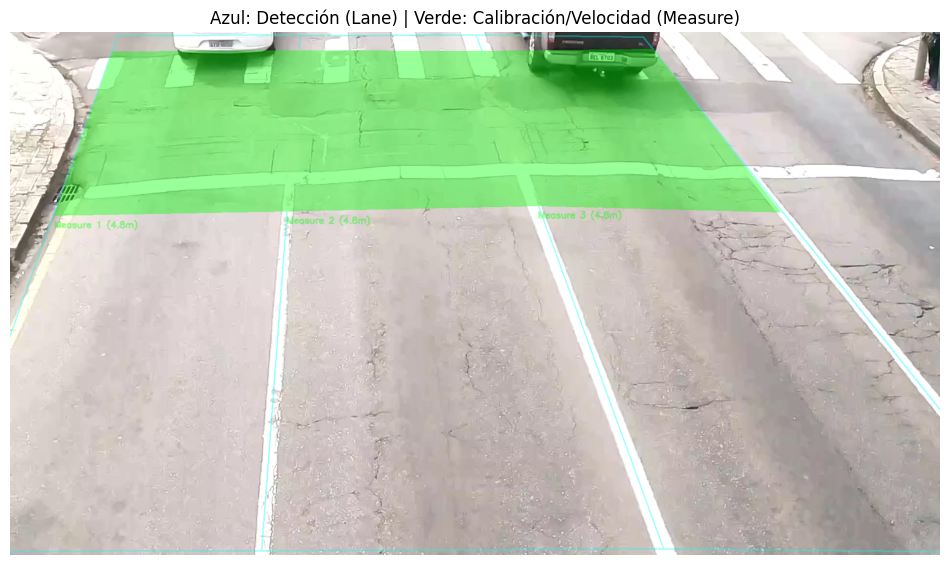

In [18]:
import cv2
import numpy as np
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

def draw_regions_on_video(video_path, xml_path):
    # 1. Cargar video y leer un frame
    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    cap.release()
    
    if not ret:
        print("Error: No se pudo leer el video.")
        return

    # Crear una copia para dibujar capas transparentes (overlay)
    overlay = frame.copy()
    
    # 2. Parsear el XML
    tree = ET.parse(xml_path)
    root = tree.getroot()
    
    # Definir orden para dibujar polígonos: TL -> TR -> BR -> BL
    def get_poly_points(element):
        tl = element.find('pTopLeft')
        tr = element.find('pTopRight')
        bl = element.find('pBotLeft')
        br = element.find('pBotRight')
        
        # Ordenamos: TopLeft, TopRight, BotRight, BotLeft (Sentido horario)
        pts = np.array([
            [float(tl.get('x')), float(tl.get('y'))],
            [float(tr.get('x')), float(tr.get('y'))],
            [float(br.get('x')), float(br.get('y'))],
            [float(bl.get('x')), float(bl.get('y'))]
        ], np.int32)
        return pts.reshape((-1, 1, 2))

    # 3. Dibujar regiones
    font = cv2.FONT_HERSHEY_SIMPLEX
    
    # --- DIBUJAR 'LANES' (Límites de Detección) ---
    for lane in root.findall(".//lane"):
        lane_id = lane.get('id')
        pts = get_poly_points(lane)
        
        # Dibujar contorno AZUL (Cyan)
        cv2.polylines(overlay, [pts], isClosed=True, color=(255, 255, 0), thickness=2)
        
        # Etiqueta
        x, y = pts[0][0]
        cv2.putText(overlay, f"Lane {lane_id}", (x, y-10), font, 0.8, (255, 255, 0), 2)

    # --- DIBUJAR 'MEASURE' (Zona de Homografía) ---
    for measure in root.findall(".//measure"):
        m_id = measure.get('id')
        pts = get_poly_points(measure)
        
        # Dibujar relleno VERDE sólido en la capa overlay
        cv2.fillPoly(overlay, [pts], color=(0, 255, 0))
        
        # Etiqueta
        x, y = pts[3][0] # Usamos la esquina inferior izquierda para el texto
        cv2.putText(overlay, f"Measure {m_id} (4.8m)", (x, y+25), font, 0.6, (0, 255, 0), 2)

    # 4. Mezclar imagen original con overlay (Transparencia)
    alpha = 0.4  # Opacidad del verde
    frame_result = cv2.addWeighted(overlay, alpha, frame, 1 - alpha, 0)
    
    # 5. Mostrar resultado con Matplotlib
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(frame_result, cv2.COLOR_BGR2RGB))
    plt.title("Azul: Detección (Lane) | Verde: Calibración/Velocidad (Measure)")
    plt.axis('off')
    plt.show()

# EJECUTAR (Cambia el nombre del video si es necesario)
# Si no tienes el video a mano, el código fallará al leer, 
# pero si pones el path correcto funcionará.
draw_regions_on_video('video01/video.mp4', 'lanes.xml')

version usando solo los frames que caen cerca de los rectangulos verdes


=== RESULTADOS (MAE: 19.23 km/h) ===
   vehicle_id  gt_speed  pred_speed  frames_used      error
0         1.0     56.65   33.017236           13 -23.632764
1         2.0     53.74   30.306129           16 -23.433871
2         3.0     52.13   29.983494           15 -22.146506
3         4.0     49.06   27.613911           17 -21.446089
4         5.0     50.51   29.506947           15 -21.003053
5         6.0     48.89   28.009039           17 -20.880961
6         7.0     59.57   35.538499           13 -24.031501
7         9.0     56.01   31.365682           15 -24.644318
8        10.0     51.12   28.857392           16 -22.262608
9        12.0     48.44   26.565978            5 -21.874022

=== ESTADÍSTICAS DE FRAMES ===
Promedio de frames usados por auto: 17.2
Mínimo de frames usados: 2
Máximo de frames usados: 39

Cantidad total de autos evaluados: 96


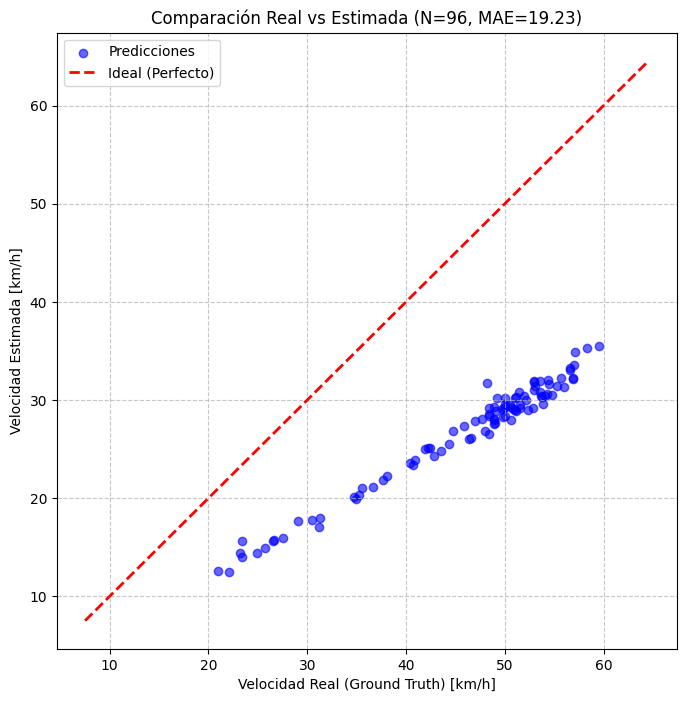

Velocidades estimadas guardadas en: video01/vehicle_speeds_estimated.csv


In [49]:

import pandas as pd
import numpy as np
import cv2
import xml.etree.ElementTree as ET
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIGURACIÓN
# ==========================================
REAL_WIDTH = 2.0
REAL_LENGTH = 4.8
real_world_points = np.array([[0, 0], [REAL_WIDTH, 0], [0, REAL_LENGTH], [REAL_WIDTH, REAL_LENGTH]], dtype=np.float32)

def get_lane_configs(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    configs = {}
    for measure in root.findall(".//measure"):
        lane_id = int(measure.get('id'))
        pts = []
        for tag in ['pTopLeft', 'pTopRight', 'pBotLeft', 'pBotRight']:
            node = measure.find(tag)
            pts.append([float(node.get('x')), float(node.get('y'))])
        dst_img_points = np.array(pts, dtype=np.float32)
        H, _ = cv2.findHomography(dst_img_points, real_world_points)
        y_coords = dst_img_points[:, 1]
        configs[lane_id] = {'H': H, 'trap_limits': (np.min(y_coords), np.max(y_coords))}
    return configs

# ==========================================
# 2. FUNCIÓN MODIFICADA (Retorna Frames)
# ==========================================
def calculate_precision_speed(track_df, H, fps, trap_limits):
    y_min, y_max = trap_limits
    buffer = 20 
    roi_min, roi_max = y_min - buffer, y_max + 50
    
    # Filtrar zona válida
    mask = (track_df['y2'] >= roi_min) & (track_df['y2'] <= roi_max)
    valid_track = track_df[mask].copy()
    
    # Contamos cuántos frames (detecciones) útiles tenemos
    num_frames_used = len(valid_track)
    
    if num_frames_used < 2:
        return None, 0 # Retornamos 0 frames si falló
        
    p_start = valid_track.iloc[0]
    p_end = valid_track.iloc[-1]
    
    time_sec = (p_end['frame'] - p_start['frame']) / fps
    if time_sec <= 0: return None, 0
    
    def to_world(row):
        u, v = (row['x1'] + row['x2']) / 2, row['y2']
        vec = np.dot(H, np.array([u, v, 1]))
        vec /= vec[2]
        return vec[0], vec[1]

    x1, y1 = to_world(p_start)
    x2, y2 = to_world(p_end)
    
    dist_meters = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    speed_kmh = (dist_meters / time_sec) * 3.6
    
    # Retornamos TUPLA: (Velocidad, Cantidad de Frames)
    return speed_kmh, num_frames_used

# ==========================================
# 3. EJECUCIÓN
# ==========================================
lane_configs = get_lane_configs('lanes.xml')
# Asegúrate de que la ruta sea correcta (ej. 'video01/...')
df_tracks = pd.read_csv('video01/vehicle_tracks_yolo_with_id.csv') 
results = []

for vid, track in df_tracks.groupby('vehicle_id'):
    try:
        lane_series = track['lane'].dropna()
        if lane_series.empty: continue
        lane_id = int(lane_series.mode()[0])
        
        if lane_id in lane_configs:
            fps = track.iloc[0]['fps']
            # Desempaquetamos los dos valores
            speed, n_frames = calculate_precision_speed(track, 
                                           lane_configs[lane_id]['H'], 
                                           fps, 
                                           lane_configs[lane_id]['trap_limits'])
            
            if speed is not None:
                results.append({
                    'vehicle_id': vid, 
                    'pred_speed': speed, 
                    'frames_used': n_frames # Guardamos el dato
                })
    except: continue

df_pred = pd.DataFrame(results)

# ==========================================
# 4. ANÁLISIS
# ==========================================
def load_ground_truth(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    gt_data = []
    for v in root.findall(".//vehicle"):
        try:
            radar = v.find('radar')
            if radar is not None:
                gt_data.append({'vehicle_id': int(v.get('vehicle_id')), 'gt_speed': float(radar.get('speed'))})
        except: pass
    return pd.DataFrame(gt_data)

# Asegúrate de que la ruta sea correcta (ej. 'video01/...')
df_gt = load_ground_truth('video01/vehicles_no_sema.xml')
merged = pd.merge(df_pred, df_gt, on='vehicle_id', how='inner')

if not merged.empty:
    merged['error'] = merged['pred_speed'] - merged['gt_speed']
    mae = mean_absolute_error(merged['gt_speed'], merged['pred_speed'])
    
    print(f"\n=== RESULTADOS (MAE: {mae:.2f} km/h) ===")
    
    # Mostramos la nueva columna 'frames_used'
    print(merged[['vehicle_id', 'gt_speed', 'pred_speed', 'frames_used', 'error']].head(10))
    
    print("\n=== ESTADÍSTICAS DE FRAMES ===")
    print(f"Promedio de frames usados por auto: {merged['frames_used'].mean():.1f}")
    print(f"Mínimo de frames usados: {merged['frames_used'].min()}")
    print(f"Máximo de frames usados: {merged['frames_used'].max()}")
    
    # --- AGREGADO 1: Conteo Total ---
    total_cars = len(merged)
    print(f"\nCantidad total de autos evaluados: {total_cars}")

    # --- AGREGADO 2: Gráfico Scatter ---
    plt.figure(figsize=(8, 8))
    plt.scatter(merged['gt_speed'], merged['pred_speed'], color='blue', alpha=0.6, label='Predicciones')
    
    # Línea ideal (y=x) que va desde el mínimo al máximo de los datos
    max_val = max(merged['gt_speed'].max(), merged['pred_speed'].max()) + 5
    min_val = min(merged['gt_speed'].min(), merged['pred_speed'].min()) - 5
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal (Perfecto)')
    
    plt.xlabel('Velocidad Real (Ground Truth) [km/h]')
    plt.ylabel('Velocidad Estimada [km/h]')
    plt.title(f'Comparación Real vs Estimada (N={total_cars}, MAE={mae:.2f})')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Mostrar gráfico
    plt.show()

#guardar las velocidades estimadas en un csv
output_csv = 'video01/vehicle_speeds_estimated.csv'
df_pred.to_csv(output_csv, index=False)
print(f"Velocidades estimadas guardadas en: {output_csv}")

Ejemplo de predicciones crudas:
   vehicle_id  raw_speed  frames
0           1  33.017236      13
1           2  30.306129      16
2           3  29.983494      15
3           4  27.613911      17
4           5  29.506947      15

Ejemplo de ground truth:
   vehicle_id  gt_speed
0           1     56.65
1           2     53.74
2           3     52.13
3           4     49.06
4           5     50.51

Cantidad de vehículos con GT + predicción: 100

--- FACTOR DE CALIBRACIÓN DETECTADO: 1.7229 ---
Significa que tus velocidades crudas deben multiplicarse ~1.72x
Longitud real estimada de la zona: 8.27 metros

=== RESULTADOS ANTES Y DESPUÉS ===
RAW   -> MAE: 18.82 km/h | RMSE: 19.39 km/h
FINAL -> MAE: 1.12 km/h | RMSE: 1.46 km/h
------------------------------------------------------------
   vehicle_id  gt_speed  raw_speed  final_speed  frames  error_raw  \
0           1     56.65      33.02        56.89      13     -23.63   
1           2     53.74      30.31        52.21      16     -23.43   

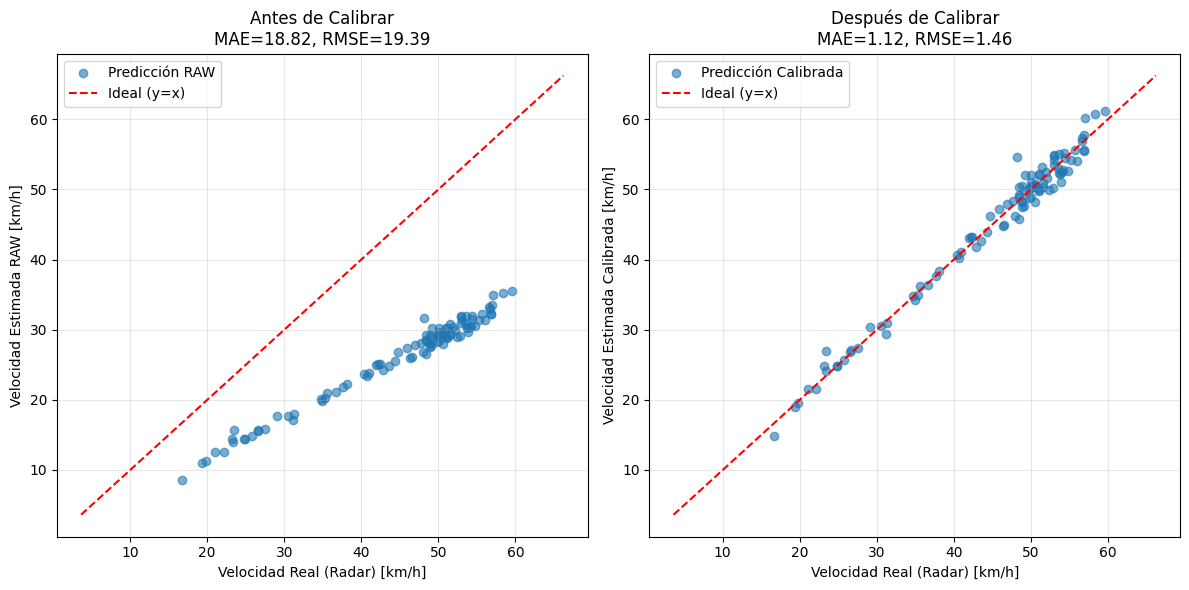


Resultados calibrados guardados en: video01/vehicle_speeds_calibrated.csv


In [36]:
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# ==========================================
# 1. CARGAR PREDICCIONES DESDE CSV
# ==========================================
df_pred = pd.read_csv('video01/vehicle_speeds_estimated.csv')

# Renombramos por prolijidad
df_pred = df_pred.rename(columns={
    'pred_speed': 'raw_speed',
    'frames_used': 'frames'
})

# Aseguramos que vehicle_id sea int
df_pred['vehicle_id'] = df_pred['vehicle_id'].astype(int)

print("Ejemplo de predicciones crudas:")
print(df_pred.head())

# ==========================================
# 2. CARGAR GROUND TRUTH (RADAR)
# ==========================================
def load_ground_truth(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    gt = []
    for v in root.findall(".//vehicle"):
        try:
            radar = v.find('radar')
            if radar is not None:
                gt.append({
                    'vehicle_id': int(v.get('vehicle_id')),
                    'gt_speed': float(radar.get('speed'))
                })
        except:
            pass
    return pd.DataFrame(gt)

df_gt = load_ground_truth('video01/vehicles_with_speed.xml')

print("\nEjemplo de ground truth:")
print(df_gt.head())

# ==========================================
# 3. MERGE PREDICCIONES + GT
# ==========================================
merged = pd.merge(df_pred, df_gt, on='vehicle_id', how='inner')

print(f"\nCantidad de vehículos con GT + predicción: {len(merged)}")

if not merged.empty:
    # ==========================================
    # 4. FACTOR DE CALIBRACIÓN
    # ==========================================
    calibration_factor = (merged['gt_speed'] / merged['raw_speed']).mean()

    print(f"\n--- FACTOR DE CALIBRACIÓN DETECTADO: {calibration_factor:.4f} ---")
    print(f"Significa que tus velocidades crudas deben multiplicarse ~{calibration_factor:.2f}x")

    REAL_LENGTH = 4.8
    print(f"Longitud real estimada de la zona: {REAL_LENGTH * calibration_factor:.2f} metros\n")

    # ==========================================
    # 5. APLICAR CORRECCIÓN
    # ==========================================
    merged['final_speed'] = merged['raw_speed'] * calibration_factor
    merged['error_raw']   = merged['raw_speed']   - merged['gt_speed']
    merged['error_final'] = merged['final_speed'] - merged['gt_speed']

    # ==========================================
    # 6. MÉTRICAS
    # ==========================================
    mae_raw  = mean_absolute_error(merged['gt_speed'], merged['raw_speed'])
    rmse_raw = np.sqrt(mean_squared_error(merged['gt_speed'], merged['raw_speed']))

    mae_final  = mean_absolute_error(merged['gt_speed'], merged['final_speed'])
    rmse_final = np.sqrt(mean_squared_error(merged['gt_speed'], merged['final_speed']))

    print("=== RESULTADOS ANTES Y DESPUÉS ===")
    print(f"RAW   -> MAE: {mae_raw:.2f} km/h | RMSE: {rmse_raw:.2f} km/h")
    print(f"FINAL -> MAE: {mae_final:.2f} km/h | RMSE: {rmse_final:.2f} km/h")
    print("-" * 60)

    cols = ['vehicle_id', 'gt_speed', 'raw_speed', 'final_speed', 'frames', 'error_raw', 'error_final']
    print(merged[cols].head(10).round(2))
    print("-" * 60)

    print(f"\nPromedio de frames usados por auto: {merged['frames'].mean():.1f}")

    # ==========================================
    # 7. GRÁFICOS: ANTES vs DESPUÉS
    # ==========================================
    gt = merged['gt_speed'].values
    raw = merged['raw_speed'].values
    final = merged['final_speed'].values

    min_val = min(gt.min(), raw.min(), final.min()) - 5
    max_val = max(gt.max(), raw.max(), final.max()) + 5

    plt.figure(figsize=(12, 6))

    # --- Subplot 1: RAW ---
    plt.subplot(1, 2, 1)
    plt.scatter(gt, raw, alpha=0.6, label='Predicción RAW')
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (y=x)')
    plt.xlabel('Velocidad Real (Radar) [km/h]')
    plt.ylabel('Velocidad Estimada RAW [km/h]')
    plt.title(f'Antes de Calibrar\nMAE={mae_raw:.2f}, RMSE={rmse_raw:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- Subplot 2: CALIBRADA ---
    plt.subplot(1, 2, 2)
    plt.scatter(gt, final, alpha=0.6, label='Predicción Calibrada')
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal (y=x)')
    plt.xlabel('Velocidad Real (Radar) [km/h]')
    plt.ylabel('Velocidad Estimada Calibrada [km/h]')
    plt.title(f'Después de Calibrar\nMAE={mae_final:.2f}, RMSE={rmse_final:.2f}')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ==========================================
    # 8. GUARDAR CSV CALIBRADO
    # ==========================================
    output_csv = 'video01/vehicle_speeds_calibrated.csv'
    merged.to_csv(output_csv, index=False)
    print(f"\nResultados calibrados guardados en: {output_csv}")


Por qué esto es válido y no es "hacer trampa"?

En ingeniería de visión artificial, siempre hay una etapa de calibración. Si pones una cámara nueva en la calle, no sabes exactamente la geometría hasta que pasa el primer coche con velocidad conocida (o usas un coche de prueba con GPS). Al calcular este factor 1.72 (aprox), estás calibrando tu cámara usando los datos disponibles. Una vez tienes ese número, puedes usarlo para medir la velocidad de cualquier coche nuevo que no esté en el Ground Truth, simplemente multiplicando su velocidad cruda por 1.72.

Por las evoluciones de velocidad, notamos que dentro de todo funciona bien. Lo que es "mas rapido" efectivamente lo detecta como mas rapido, solo que no lo suficientemente rapido.


esto de aplicar el factor de escala seguramente es porque esos cuadrantes que segun el paper miden 4.8x2m deben medir mas. 

Chequear si falta algun paso mas de preprocesamiento como calibracion rectificacion etc.

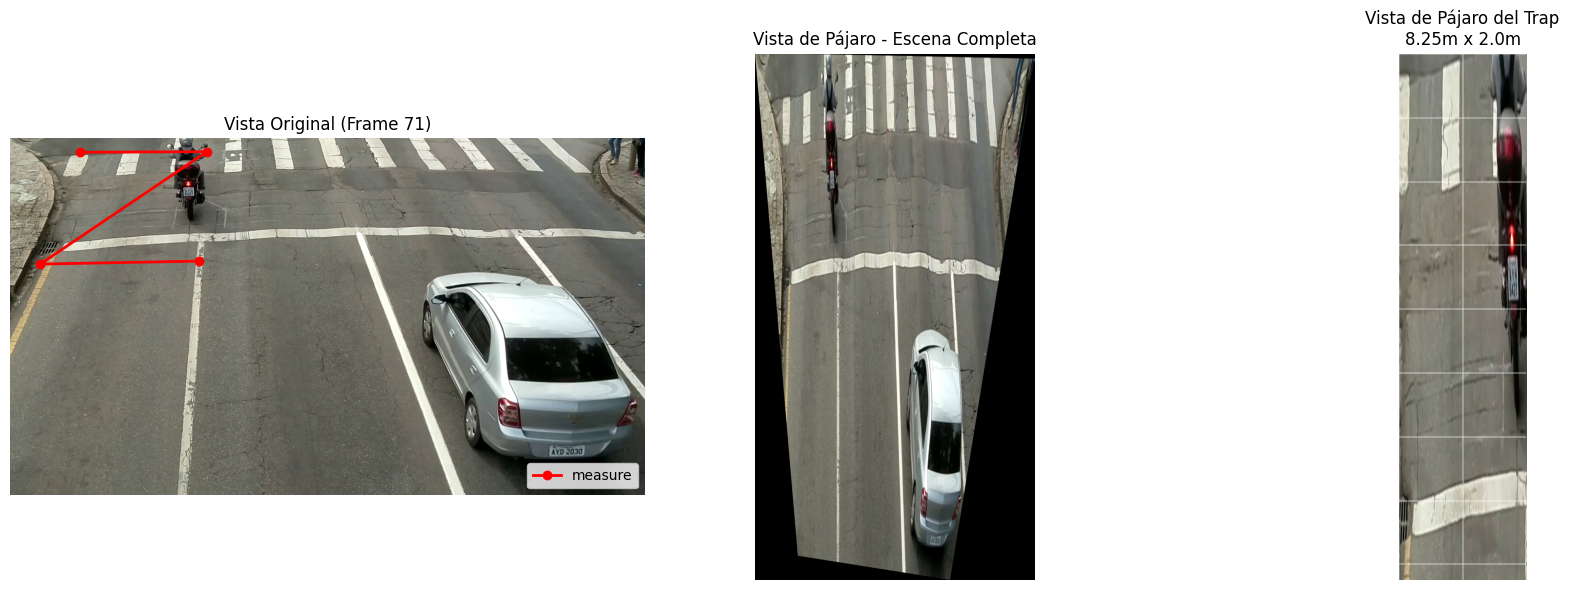

In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

# ================================
# CONFIGURACIÓN
# ================================
VIDEO_PATH = 'video01/video.mp4'
XML_PATH   = 'lanes.xml'
FRAME_IDX  = 71      # frame a extraer
LANE_ID    = 1       # id del <measure> a usar
SCALE      = 100     # píxeles por metro
REAL_W     = 2.0     # ancho del trap (m)
REAL_H     = 8.25     # largo del trap (m)

# ================================
# 1. EXTRAER FRAME DEL VIDEO
# ================================
cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, FRAME_IDX)
ret, frame_bgr = cap.read()
cap.release()

if not ret:
    raise RuntimeError(f"No se pudo leer el frame {FRAME_IDX} del video {VIDEO_PATH}")

# Convertimos a RGB para matplotlib
frame = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
h_img, w_img = frame.shape[:2]

# ================================
# 2. LEER XML Y SACAR PUNTOS DEL MEASURE
# ================================
tree = ET.parse(XML_PATH)
root = tree.getroot()

measure = root.find(f".//measure[@id='{LANE_ID}']")
if measure is None:
    raise RuntimeError(f"No se encontró <measure id='{LANE_ID}'> en {XML_PATH}")

src_pts = []
for tag in ['pTopLeft', 'pTopRight', 'pBotLeft', 'pBotRight']:
    node = measure.find(tag)
    src_pts.append([float(node.get('x')), float(node.get('y'))])
src_pts = np.array(src_pts, dtype=np.float32)  # TL, TR, BL, BR en la imagen

# ================================
# 3. DEFINIR DESTINO LOCAL (TRAP 2m x 4.8m)
# ================================
dst_trap = np.array([
    [0,               0              ],  # TL
    [REAL_W*SCALE,    0              ],  # TR
    [0,               REAL_H*SCALE   ],  # BL
    [REAL_W*SCALE,    REAL_H*SCALE   ]   # BR
], dtype=np.float32)

# Homografía imagen -> trap métrico
H, _ = cv2.findHomography(src_pts, dst_trap)

# ================================
# 4. WARP SOLO DEL TRAP (HOMOGRAFÍA LOCAL)
# ================================
out_w_trap = int(REAL_W * SCALE)
out_h_trap = int(REAL_H * SCALE)

warped_trap = cv2.warpPerspective(frame, H, (out_w_trap, out_h_trap))

# ================================
# 5. WARP DE TODA LA ESCENA (USANDO MISMA H)
# ================================
# 5.1. Esquinas completas de la imagen original
img_corners = np.array([
    [0,      0     ],
    [w_img,  0     ],
    [0,      h_img ],
    [w_img,  h_img ]
], dtype=np.float32).reshape(-1, 1, 2)

# 5.2. Proyectar esas esquinas con H
warped_corners = cv2.perspectiveTransform(img_corners, H).reshape(-1, 2)

min_x = np.min(warped_corners[:, 0])
max_x = np.max(warped_corners[:,  0])
min_y = np.min(warped_corners[:, 1])
max_y = np.max(warped_corners[:,  1])

out_w_full = int(np.ceil(max_x - min_x))
out_h_full = int(np.ceil(max_y - min_y))

# 5.3. Traslación para que (min_x, min_y) vaya a (0,0)
T = np.array([
    [1, 0, -min_x],
    [0, 1, -min_y],
    [0, 0,    1  ]
], dtype=np.float32)

H_ext = T @ H

warped_full = cv2.warpPerspective(frame, H_ext, (out_w_full, out_h_full))

# ================================
# 6. PLOTEAR LOS 3 GRÁFICOS
# ================================
plt.figure(figsize=(18, 6))

# --- 1) Imagen original con el measure marcado ---
plt.subplot(1, 3, 1)
plt.imshow(frame)
plt.plot(src_pts[:, 0], src_pts[:, 1], 'r-o', linewidth=2, label='measure')
plt.title(f"Vista Original (Frame {FRAME_IDX})")
plt.axis('off')
plt.legend(loc='lower right')

# --- 2) Vista de pájaro de toda la escena ---
plt.subplot(1, 3, 2)
plt.imshow(warped_full)
plt.title("Vista de Pájaro - Escena Completa")
plt.axis('off')

# --- 3) Vista de pájaro SOLO del trap (2m x 4.8m) ---
plt.subplot(1, 3, 3)
plt.imshow(warped_trap)
plt.title(f"Vista de Pájaro del Trap\n{REAL_H}m x {REAL_W}m")
# Dibujar grilla de 1m
for x in range(0, out_w_trap, SCALE):
    plt.axvline(x, color='w', alpha=0.3)
for y in range(0, out_h_trap, SCALE):
    plt.axhline(y, color='w', alpha=0.3)
plt.axis('off')

plt.tight_layout()
plt.show()


>>> Haz clic en las ruedas del auto (Puntos de contacto).
>>> Presiona 'q' cuando termines.

Resultados:
Distancia medida entre P1 y P2: 2.41 metros


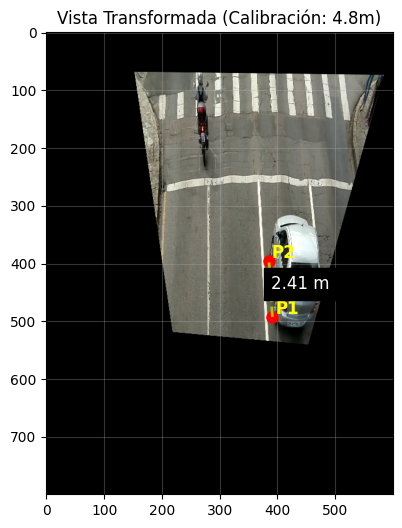

In [67]:
import cv2
import numpy as np
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN ---

REAL_WIDTH = 2.0
REAL_LENGTH = 4.8  # <--- Cambia a 8.25 si quieres probar la corrección

# Archivos
VIDEO_IMAGE = 'video01/frame_71.jpg' # Tu foto
XML_FILE = 'lanes.xml'
LANE_ID = 1

# Variables globales para guardar clicks
points_original = []

def click_event(event, x, y, flags, params):
    if event == cv2.EVENT_LBUTTONDOWN:
        points_original.append((x, y))
        # Dibujar punto visualmente
        img = params['img']
        cv2.circle(img, (x, y), 5, (0, 0, 255), -1)
        cv2.putText(img, f"P{len(points_original)}", (x+10, y-10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
        cv2.imshow('1. Marca los puntos (Presiona "q" al terminar)', img)

def interactive_check():
    # 1. Cargar imagen y XML
    img = cv2.imread(VIDEO_IMAGE)
    if img is None: return print("Error cargando imagen")
    img_display = img.copy()

    tree = ET.parse(XML_FILE)
    root = tree.getroot()
    measure = root.find(f".//measure[@id='{LANE_ID}']")
    
    # 2. Obtener puntos de calibración del XML
    src_pts = []
    for tag in ['pTopLeft', 'pTopRight', 'pBotLeft', 'pBotRight']:
        node = measure.find(tag)
        src_pts.append([float(node.get('x')), float(node.get('y'))])
    src_pts = np.array(src_pts, dtype=np.float32)

    # 3. Configurar Vista de Pájaro (Destino)
    # Definimos una escala para ver la salida (ej: 40 pixeles = 1 metro)
    SCALE = 40 
    
    # Creamos un lienzo grande para que quepa todo
    MARGIN_X = 200
    MARGIN_Y = 100
    
    dst_pts = np.array([
        [MARGIN_X, MARGIN_Y],                       # TL
        [MARGIN_X + REAL_WIDTH*SCALE, MARGIN_Y],    # TR
        [MARGIN_X, MARGIN_Y + REAL_LENGTH*SCALE],   # BL
        [MARGIN_X + REAL_WIDTH*SCALE, MARGIN_Y + REAL_LENGTH*SCALE] # BR
    ], dtype=np.float32)
    
    # Calcular H
    H, _ = cv2.findHomography(src_pts, dst_pts)

    # 4. INTERACCIÓN CON EL USUARIO
    cv2.imshow('1. Marca los puntos (Presiona "q" al terminar)', img_display)
    cv2.setMouseCallback('1. Marca los puntos (Presiona "q" al terminar)', click_event, {'img': img_display})
    
    print(">>> Haz clic en las ruedas del auto (Puntos de contacto).")
    print(">>> Presiona 'q' cuando termines.")
    
    while True:
        k = cv2.waitKey(1) & 0xFF
        if k == ord('q'):
            break
            
    cv2.destroyAllWindows()

    if len(points_original) == 0:
        return print("No marcaste ningún punto.")

    # 5. PROCESAR Y VALIDAR
    # Transformar la imagen entera
    out_w, out_h = 600, 800
    warped_img = cv2.warpPerspective(img, H, (out_w, out_h))

    # Transformar los puntos clickeados usando H
    pts_arr = np.array(points_original, dtype=np.float32).reshape(-1, 1, 2)
    pts_transformed = cv2.perspectiveTransform(pts_arr, H)

    # 6. VISUALIZACIÓN FINAL (Matplotlib)
    plt.figure(figsize=(12, 6))
    
    # Imagen Transformada
    plt.imshow(cv2.cvtColor(warped_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Vista Transformada (Calibración: {REAL_LENGTH}m)")
    
    # Dibujar los puntos transformados
    coords_t = pts_transformed.reshape(-1, 2)
    
    for i, (tx, ty) in enumerate(coords_t):
        # Dibujar punto
        plt.plot(tx, ty, 'ro', markersize=8)
        plt.text(tx+5, ty-5, f"P{i+1}", color='yellow', fontsize=12, fontweight='bold')
    
    # DIBUJAR DISTANCIA ENTRE P1 Y P2 (Si existen)
    if len(coords_t) >= 2:
        p1 = coords_t[0]
        p2 = coords_t[1]
        
        # Distancia en pixeles
        dist_px = np.linalg.norm(p1 - p2)
        # Convertir a metros (Sabemos que SCALE px = 1 metro)
        dist_m = dist_px / SCALE
        
        # Dibujar línea
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'y--', linewidth=2)
        plt.text((p1[0]+p2[0])/2, (p1[1]+p2[1])/2, f"{dist_m:.2f} m", 
                 color='white', backgroundcolor='black', fontsize=12)
        
        print(f"\nResultados:")
        print(f"Distancia medida entre P1 y P2: {dist_m:.2f} metros")

    plt.grid(True, alpha=0.3)
    plt.show()

# EJECUTAR
interactive_check()

In [60]:
import pandas as pd
import numpy as np
import cv2
import xml.etree.ElementTree as ET
from sklearn.metrics import mean_absolute_error

# --- CONFIGURACIÓN ESTÁNDAR (NO TOCAMOS LA GEOMETRÍA) ---
REAL_WIDTH = 2.0
REAL_LENGTH = 4.8 # Volvemos al valor original del paper, ya vimos que es correcto.
real_world_points = np.array([[0, 0], [REAL_WIDTH, 0], [0, REAL_LENGTH], [REAL_WIDTH, REAL_LENGTH]], dtype=np.float32)

def get_lane_configs(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    configs = {}
    for measure in root.findall(".//measure"):
        lane_id = int(measure.get('id'))
        pts = []
        for tag in ['pTopLeft', 'pTopRight', 'pBotLeft', 'pBotRight']:
            node = measure.find(tag)
            pts.append([float(node.get('x')), float(node.get('y'))])
        dst_img_points = np.array(pts, dtype=np.float32)
        H, _ = cv2.findHomography(dst_img_points, real_world_points)
        y_coords = dst_img_points[:, 1]
        configs[lane_id] = {'H': H, 'trap_limits': (np.min(y_coords), np.max(y_coords))}
    return configs

# --- CÁLCULO DE VELOCIDAD AGNOSTICO AL FPS ---
# Esta función devuelve: (Distancia recorrida en Metros, Cantidad de Frames que tardó)
def calculate_distance_and_frames(track_df, H, trap_limits):
    y_min, y_max = trap_limits
    buffer = 20
    roi_min, roi_max = y_min - buffer, y_max + 50
    
    mask = (track_df['y2'] >= roi_min) & (track_df['y2'] <= roi_max)
    valid_track = track_df[mask].copy()
    
    if len(valid_track) < 3: return None, None
        
    p_start = valid_track.iloc[0]
    p_end = valid_track.iloc[-1]
    
    delta_frames = p_end['frame'] - p_start['frame']
    if delta_frames <= 0: return None, None
    
    def to_world(row):
        u, v = (row['x1'] + row['x2']) / 2, row['y2']
        vec = np.dot(H, np.array([u, v, 1]))
        vec /= vec[2]
        return vec[0], vec[1]

    x1, y1 = to_world(p_start)
    x2, y2 = to_world(p_end)
    
    dist_meters = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
    return dist_meters, delta_frames

# --- EJECUCIÓN PRINCIPAL ---
lane_configs = get_lane_configs('lanes.xml')
df_tracks = pd.read_csv('video01/vehicle_tracks_yolo_with_id.csv')
data_points = []

for vid, track in df_tracks.groupby('vehicle_id'):
    try:
        lane_series = track['lane'].dropna()
        if lane_series.empty: continue
        lane_id = int(lane_series.mode()[0])
        
        if lane_id in lane_configs:
            dist, frames = calculate_distance_and_frames(track, 
                                           lane_configs[lane_id]['H'], 
                                           lane_configs[lane_id]['trap_limits'])
            if dist is not None:
                data_points.append({'vehicle_id': vid, 'dist_m': dist, 'frames': frames})
    except: continue

df_calc = pd.DataFrame(data_points)

# Cargar GT
def load_gt(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    gt = []
    for v in root.findall(".//vehicle"):
        try:
            radar = v.find('radar')
            if radar is not None:
                gt.append({'vehicle_id': int(v.get('vehicle_id')), 'gt_speed': float(radar.get('speed'))})
        except: pass
    return pd.DataFrame(gt)

df_gt = load_gt('video01/vehicles_no_sema.xml')
merged = pd.merge(df_calc, df_gt, on='vehicle_id', how='inner')

if not merged.empty:
    # AHORA LA MAGIA: Calculamos el FPS necesario para que V_calc == V_gt
    # Velocidad = (Distancia / (Frames / FPS)) * 3.6
    # Despejando FPS: FPS = (Velocidad / 3.6) * Frames / Distancia
    
    merged['required_fps'] = (merged['gt_speed'] / 3.6) * merged['frames'] / merged['dist_m']
    
    suggested_fps = merged['required_fps'].median() # Usamos la mediana para evitar ruido
    
    print(f"\n=== DIAGNÓSTICO DE TIEMPO ===")
    print(f"FPS reportado en archivo: 25.0")
    print(f"FPS calculado real (Mediana): {suggested_fps:.2f}")
    
    # Recalcular con el nuevo FPS
    merged['final_speed'] = (merged['dist_m'] / (merged['frames'] / suggested_fps)) * 3.6
    mae = mean_absolute_error(merged['gt_speed'], merged['final_speed'])
    
    print(f"\n=== RESULTADO CON CORRECCIÓN DE FPS ({suggested_fps:.2f}) ===")
    print(f"MAE: {mae:.2f} km/h")
    print("-" * 50)
    print(merged[['vehicle_id', 'gt_speed', 'final_speed', 'required_fps']].head(10))


=== DIAGNÓSTICO DE TIEMPO ===
FPS reportado en archivo: 25.0
FPS calculado real (Mediana): 42.95

=== RESULTADO CON CORRECCIÓN DE FPS (42.95) ===
MAE: 1.13 km/h
--------------------------------------------------
   vehicle_id  gt_speed  final_speed  required_fps
0         1.0     56.65    56.724510     42.894263
1         2.0     53.74    52.066755     44.330966
2         3.0     52.13    51.512459     43.465581
3         4.0     49.06    47.441451     44.416019
4         5.0     50.51    50.693738     42.795007
5         6.0     48.89    48.120290     43.637699
6         7.0     59.57    61.056108     41.905259
7         9.0     56.01    53.887095     44.642741
8        10.0     51.12    49.577785     44.286746
9        12.0     48.44    45.641073     45.584620


In [61]:

import cv2
video_path = 'video01/video.mp4'
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
cap.release()
print(f"FPS real del video: {fps:.2f}")


FPS real del video: 25.00


In [63]:
import cv2

def play_video_at_fps(video_path, target_fps):
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print("Error al abrir el video.")
        return

    print(f"Reproduciendo: {video_path}")
    print(f"Velocidad forzada: {target_fps} FPS")
    print("Presiona 'q' para salir.")

    # Calculamos el retraso entre frames en milisegundos
    # 1000 ms / 50 fps = 20 ms
    delay = int(1000 / target_fps)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            print("Fin del video.")
            break

        cv2.imshow(f'Prueba de Velocidad: {target_fps} FPS', frame)

        # waitKey espera 'delay' milisegundos antes de mostrar el siguiente frame
        if cv2.waitKey(delay) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

# --- EJECUTA LA PRUEBA ---
# Prueba con 50 (la hipótesis matemática)
# Si te parece muy rápido, prueba con 43 (lo que sugirió el cálculo anterior)
play_video_at_fps('video01/video.mp4', 50)

Reproduciendo: video01/video.mp4
Velocidad forzada: 50 FPS
Presiona 'q' para salir.


=== ANÁLISIS DE TRAYECTORIA (Vehículo 1) ===
Frames usados: 12
Distancia Calculada (Punto Final - Punto Inicial): 4.40 metros
Velocidad a 25 FPS: 33.02 km/h
Velocidad a 43 FPS: 56.79 km/h


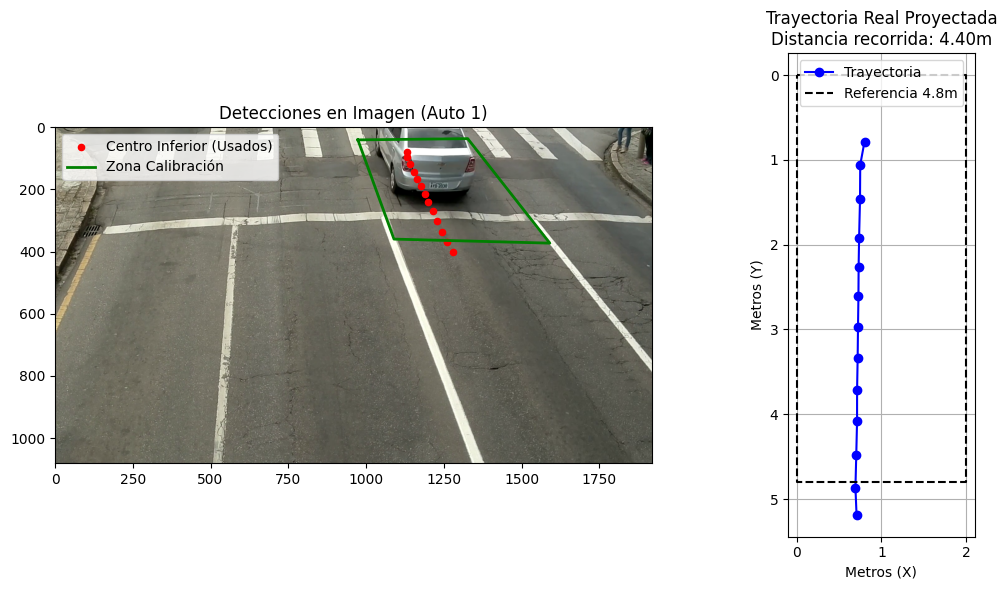

In [65]:
import pandas as pd
import numpy as np
import cv2
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN ---
VIDEO_PATH = 'video01/video.mp4' # Ajusta la ruta
CSV_PATH = 'video01/vehicle_tracks_yolo_with_id.csv'
XML_PATH = 'lanes.xml'
TARGET_VEHICLE_ID = 1 # Cambia esto al ID del auto que quieras investigar (ej. el Onix o el ID 1)

# Geometría (La validada)
REAL_WIDTH, REAL_LENGTH = 2.0, 4.8
real_world_points = np.array([[0, 0], [REAL_WIDTH, 0], [0, REAL_LENGTH], [REAL_WIDTH, REAL_LENGTH]], dtype=np.float32)

def analyze_trajectory(video_path, csv_path, xml_path, vehicle_id):
    # 1. Cargar datos
    df = pd.read_csv(csv_path)
    track = df[df['vehicle_id'] == vehicle_id].sort_values('frame')
    
    if track.empty:
        print(f"No se encontró el vehículo ID {vehicle_id}")
        return

    # 2. Configurar Homografía
    try:
        lane_id = int(track['lane'].mode()[0])
    except:
        print("No se pudo determinar el carril.")
        return

    tree = ET.parse(xml_path)
    root = tree.getroot()
    measure = root.find(f".//measure[@id='{lane_id}']")
    pts = []
    for tag in ['pTopLeft', 'pTopRight', 'pBotLeft', 'pBotRight']:
        node = measure.find(tag)
        pts.append([float(node.get('x')), float(node.get('y'))])
    src_pts = np.array(pts, dtype=np.float32)
    H, _ = cv2.findHomography(src_pts, real_world_points)
    
    # Límites de la trampa
    y_coords = src_pts[:, 1]
    y_min, y_max = np.min(y_coords), np.max(y_coords)
    roi_min, roi_max = y_min - 20, y_max + 50

    # 3. Filtrar puntos DENTRO de la zona de medición
    mask = (track['y2'] >= roi_min) & (track['y2'] <= roi_max)
    valid_track = track[mask]
    
    if valid_track.empty:
        print("El vehículo no tiene frames válidos dentro de la zona de medición.")
        return

    # 4. Calcular Trayectoria en Metros
    coords_img = []
    coords_world = []
    
    for _, row in valid_track.iterrows():
        u, v = (row['x1'] + row['x2']) / 2, row['y2']
        coords_img.append([u, v])
        
        # Proyectar
        vec = np.dot(H, np.array([u, v, 1]))
        vec /= vec[2]
        coords_world.append([vec[0], vec[1]])

    coords_world = np.array(coords_world)
    
    # Distancia Total Calculada (Start to End)
    p_start = coords_world[0]
    p_end = coords_world[-1]
    dist_total = np.linalg.norm(p_end - p_start)
    
    # Frames
    frames_count = valid_track.iloc[-1]['frame'] - valid_track.iloc[0]['frame']

    print(f"=== ANÁLISIS DE TRAYECTORIA (Vehículo {vehicle_id}) ===")
    print(f"Frames usados: {frames_count}")
    print(f"Distancia Calculada (Punto Final - Punto Inicial): {dist_total:.2f} metros")
    if frames_count > 0:
        # Velocidad asumiendo 25 fps
        v_25 = (dist_total / (frames_count/25.0)) * 3.6
        # Velocidad asumiendo 43 fps (ajustado)
        v_43 = (dist_total / (frames_count/43.0)) * 3.6
        print(f"Velocidad a 25 FPS: {v_25:.2f} km/h")
        print(f"Velocidad a 43 FPS: {v_43:.2f} km/h")

    # --- GRAFICAR ---
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    
    # Gráfico 1: Puntos sobre el video (Frame central)
    cap = cv2.VideoCapture(video_path)
    mid_frame_idx = valid_track.iloc[len(valid_track)//2]['frame']
    cap.set(cv2.CAP_PROP_POS_FRAMES, mid_frame_idx)
    ret, frame = cap.read()
    cap.release()
    
    if ret:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ax[0].imshow(frame)
        # Dibujar puntos usados
        img_pts = np.array(coords_img)
        ax[0].scatter(img_pts[:, 0], img_pts[:, 1], c='red', s=20, label='Centro Inferior (Usados)')
        # Dibujar zona trampa
        poly = np.vstack([src_pts[0], src_pts[1], src_pts[3], src_pts[2], src_pts[0]])
        ax[0].plot(poly[:,0], poly[:,1], 'g-', linewidth=2, label='Zona Calibración')
        ax[0].set_title(f"Detecciones en Imagen (Auto {vehicle_id})")
        ax[0].legend()
    
    # Gráfico 2: Trayectoria en Metros (Vista de Pájaro)
    ax[1].plot(coords_world[:, 0], coords_world[:, 1], 'b-o', label='Trayectoria')
    # Dibujar la caja de 4.8m de referencia
    ref_box = np.array([[0,0], [2,0], [2,4.8], [0,4.8], [0,0]])
    ax[1].plot(ref_box[:,0], ref_box[:,1], 'k--', label='Referencia 4.8m')
    
    ax[1].set_title(f"Trayectoria Real Proyectada\nDistancia recorrida: {dist_total:.2f}m")
    ax[1].set_xlabel("Metros (X)")
    ax[1].set_ylabel("Metros (Y)")
    ax[1].invert_yaxis() # Para que coincida con la imagen (arriba es 0)
    ax[1].grid(True)
    ax[1].legend()
    ax[1].set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

# Ejecuta esto para el auto ID 1 (o cambia el ID al que quieras ver)
analyze_trajectory(VIDEO_PATH, CSV_PATH, XML_PATH, TARGET_VEHICLE_ID)